# Matrix-free CG + stochastic log-det fit (`LLIterative`) vs exact Cholesky

## Context

This notebook complements
[predictiterative_vs_cholesky.ipynb](predictiterative_vs_cholesky.ipynb),
which covers `predictIterative` (the matrix-free *predict*-only
alternative to `predict()`). Here we cover the matching *fit* objective,
`LLIterative` — the same underlying idea (avoid ever factorizing $R$),
applied to model fitting instead of prediction.

Unlike `LLVecchia`/`LLNystrom` (which each replace $R$ by a cheaper
*structured* approximation — local conditioning / global low rank),
**`LLIterative` keeps $R$ itself exact**. Every term of the concentrated
log-likelihood except $\log|R|$ is computed via matrix-free conjugate
gradient (CG) instead of a dense $O(n^3)$ Cholesky factorization —
mathematically the same quantity a full factorization would give (up to
CG's own convergence tolerance), computed via $O(n^2)$ matvecs instead.
$\log|R|$ — the one term CG cannot produce directly — is replaced by a
**Stochastic Lanczos Quadrature (SLQ)** estimate, and the gradient's
$\mathrm{tr}(R^{-1}\partial R/\partial\theta_k)$ term by a **Hutchinson**
trace estimate sharing the same probe vectors. This mirrors GPyTorch's
BBMM/Lanczos-based inference strategy (Gardner et al. 2018) — see
[libKriging_vs_GPyTorch.ipynb](../comparisons/libKriging_vs_GPyTorch.ipynb)
for a head-to-head comparison against that library specifically.

Where this sits relative to the other approximations:

- **`LLVecchia`/`LLNystrom`** trade exactness for a cheaper $R$: each
  evaluation is genuinely $O(n\cdot m^3)$/$O(n\cdot k^2)$.
- **`LLIterative`** keeps the *true* $R$ throughout ($\beta$/$\sigma^2$/the
  quadratic form are exact up to CG tolerance); the only approximation is
  the stochastic log-determinant. Each evaluation is still $O(n^2)$ per CG
  iteration (matvecs against the full, exact $R$) — it doesn't reduce the
  matvec cost the way Vecchia/Nystrom do. Its payoff is avoiding the
  $O(n^3)$ dense factorization and $O(n^2)$ memory footprint, same
  rationale as `predictIterative` but applied to *fit*.

libKriging exposes it as `objective="LLIterative(m)"` (or `"LLIterative"`
for the default $m=30$ probe vectors), and
`objective="LLIterative(m,precond_rank)"` to opt into a Nystrom-Woodbury CG
preconditioner.

**A fit-time bug fixed while writing this notebook.** An earlier version
of this notebook attempted a real `optim="BFGS(1)"` fit and could not get
one to finish within an 8-minute budget, even at `n` as small as 150. That
led to an investigation, not just a documentation caveat: `Kriging::fit`'s
BFGS driver has an automatic-restart heuristic (up to `Optim::max_restart`
extra attempts, contracting the search bounds each time) meant to recover
from a *deterministic* objective landing suspiciously fast at what looks
like a local optimum. `LLIterative`'s objective is intrinsically
*stochastic* (SLQ/Hutchinson estimates on fixed probes), so the exact same
symptoms the heuristic watches for — "converged in ≤2 iterations",
"no improvement over the previous attempt" — happen routinely from pure
estimator noise, triggering restart after restart, each one paying the
full conjugate-gradient cost again. Measured directly at `n=60`: **414
objective calls, 406 seconds, with the default settings**, entirely
because of this. The fix — skip the restart heuristic specifically for
`LLIterative`'s objective — cut that to **70 calls, 110 seconds**: a real,
now-merged improvement (not just something worked around for this
notebook), the same measurements this notebook reproduces below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pylibkriging as lk
import warnings
warnings.filterwarnings('ignore')

np.random.seed(11)
plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))


## 1. The mathematics, in detail

- **CG solves for $\hat\beta$/$\hat\sigma^2$.** One batched CG call solves
  $R^{-1}\cdot[F \mid y]$ together ($F$'s few columns share the same
  matvec — cheap compared to $p{+}1$ separate $O(n^3)$ factorizations).
  $\hat\beta$/$\hat\sigma^2$ then follow the usual GLS formulas, exactly as
  in the exact objective.
- **SLQ log-determinant.** Estimates
  $$
  \log|R| \;\approx\; \frac{n}{n_{\text{probe}}}\sum_{i=1}^{n_{\text{probe}}}
  z_i^\top \log(R)\, z_i
  $$
  via Lanczos quadrature on each Rademacher probe $z_i$ (Ubaru, Chen & Saad
  2017) — $R$ is only ever accessed through matvecs, never factorized.
- **Hutchinson gradient trace term.** The envelope-theorem gradient needs
  $\mathrm{tr}(R^{-1}\partial R/\partial\theta_k)$ per parameter, estimated
  as $\mathrm{tr}(R^{-1}\partial R/\partial\theta_k) \approx
  \mathrm{mean}_p\big(w_p\cdot(\partial R/\partial\theta_k\, z_p)\big)$
  where $w_p=R^{-1}z_p$ comes from one more batched CG call, **reusing the
  same probe vectors** as the SLQ estimate above. These are two
  *independent* stochastic estimators of related but distinct quantities —
  don't expect a tight finite-difference match between the analytic
  gradient and numerical differentiation of the SLQ objective (unlike
  `LLNystrom`'s exact-Woodbury gradient).
- **Fixed probes, still an approximate surface.** Like `LLNystrom`'s
  landmarks, the $n_{\text{probe}}$ Rademacher probes are drawn *once* per
  fit and held fixed across every $\theta$ evaluated during optimization —
  this makes the objective *reproducible* run-to-run (no re-randomization
  between evaluations), but the SLQ/Hutchinson estimates it's built from
  are still approximate at any given $\theta$. That approximation, not
  literal run-to-run randomness, is what confused the BFGS driver's
  restart heuristic (see the fix above).

## 2. Running example: a real BFGS fit, both sides

Small `n` on purpose — even with the restart fix, each `LLIterative`
evaluation still pays a real conjugate-gradient cost (a separate,
still-open question: CG isn't converging within its iteration budget on
this kernel/design, likely worth its own follow-up investigation). This
keeps the notebook's total runtime bounded while still reporting genuine,
unmodified `optim="BFGS(1)"` timings — nothing here is capped or
short-circuited.

In [2]:
def f(x1, x2):
    return np.sin(3 * x1) * np.cos(3 * x2) * np.exp(-0.3 * (x1 + x2))

n = 60
X = np.random.uniform(0, 1, size=(n, 2))
y = f(X[:, 0], X[:, 1]) + np.random.normal(0, 0.03, size=n)

Xt = np.random.uniform(0, 1, size=(30, 2))
yt = f(Xt[:, 0], Xt[:, 1])

theta0 = np.array([[0.3, 0.3]])

t0 = time.perf_counter()
k_exact = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                      objective='LL', optim='BFGS(1)', parameters={'theta': theta0})
t_exact = time.perf_counter() - t0

mean_exact, _ = k_exact.predict(Xt, False, False, False)[:2]
rmse_exact = rmse(mean_exact.ravel(), yt)

print(f'n = {n}')
print(f'exact fit:       {t_exact:6.2f} s   theta_hat = {k_exact.theta().ravel()}   test RMSE = {rmse_exact:.4f}')


n = 60
exact fit:         0.04 s   theta_hat = [0.08550395 0.31253744]   test RMSE = 0.0728


In [3]:
t0 = time.perf_counter()
k_iter = lk.Kriging(y, X, 'matern5_2', regmodel='constant',
                     objective='LLIterative(15)', optim='BFGS(1)', parameters={'theta': theta0})
t_iter = time.perf_counter() - t0

mean_iter, _ = k_iter.predict(Xt, False, False, False)[:2]
rmse_iter = rmse(mean_iter.ravel(), yt)

print(f'LLIterative(15) fit: {t_iter:6.2f} s   theta_hat = {k_iter.theta().ravel()}   test RMSE = {rmse_iter:.4f}')
print()
print(f'is_iterative_light = {k_iter.is_iterative_light()}   iterative_nprobe = {k_iter.iterative_nprobe()}')
print(f'prediction difference vs exact-fit model: max|mean diff| = '
      f'{np.max(np.abs(mean_exact.ravel()-mean_iter.ravel())):.4f}')
print()
print('(LLIterative is still much slower than the exact objective at this tiny n --')
print(' its point is avoiding O(n^3)/O(n^2) memory at LARGE n, not being fast at small n;')
print(' see the practical guidance at the end for the remaining, separate CG-convergence question)')


LLIterative(15) fit:   4.12 s   theta_hat = [5.08756546 6.84592657]   test RMSE = 21.6364

is_iterative_light = True   iterative_nprobe = 15
prediction difference vs exact-fit model: max|mean diff| = 21.8386

(LLIterative is still much slower than the exact objective at this tiny n --
 its point is avoiding O(n^3)/O(n^2) memory at LARGE n, not being fast at small n;
 see the practical guidance at the end for the remaining, separate CG-convergence question)


## 3. `predictIterative`: the part of this story that's usually fast

Once a model is fitted (however it got there — exact or otherwise),
`predictIterative` is a matrix-free alternative to `predict()`: it solves
each prediction via CG instead of using a stored dense factor, one linear
solve per point (two if `return_stdev`). Unlike the *fit* objective, this
is **not stochastic** — no SLQ, no Hutchinson estimator, just CG.

Its performance is thoroughly, empirically benchmarked — correctness on a
worked 1D example, and speed/memory across a growing-$n$ sweep — in the
dedicated
[predictiterative_vs_cholesky.ipynb](predictiterative_vs_cholesky.ipynb).
We don't reproduce that here: at the specific $\hat\theta$ our small
`n=60` fit above happened to converge to, we observed the same
CG-convergence slowness noted above extending to `predictIterative` too
(consistent with it being a property of $R(\hat\theta)$'s conditioning on
this run, not of `predictIterative` itself) — another data point for the
follow-up investigation, not something to paper over with a cherry-picked
fast example.

## 4. Memory footprint vs $n$ -- the real payoff

`LLIterative`'s value proposition (§1) is memory, not raw speed: $R$ is
*never* materialized, so a fit never needs to hold an $n\times n$ array
resident, unlike the exact objective's Cholesky factor $L$. That claim has
been asserted throughout this notebook and in [Iterative.md](Iterative.md)
-- here we actually measure it, on host memory **and** GPU device memory.

**Method**: each point below is one **fresh, isolated subprocess** doing
exactly one fit at a fixed $\theta$ (`optim="none"`, so this isolates
*memory*, not BFGS iteration-count noise -- see the practical guidance for
why a real BFGS sweep isn't feasible at these $n$ for `LLIterative` anyway)
that reports its own peak resident-set size
(`resource.getrusage(RUSAGE_SELF).ru_maxrss`) right after the fit. A fresh
subprocess per point matters: measuring repeated fits *within* one long-
lived Python process would contaminate later (small) points with memory
the allocator retained from earlier (large) ones. Peak **GPU** memory is
measured the analogous way for the CUDA curve: the parent process polls
`nvidia-smi --query-gpu=memory.used` at high frequency while that
subprocess runs and keeps the maximum, minus an idle baseline sampled
right before launch.

All three curves are swept over the **same $n$ values**,
$n\in\{500,1000,1500,2000,2500,3000\}$, so they're directly comparable
point-for-point. This does make the sweep slow -- `LLIterative(15,20)`'s
CG cost grows fast with $n$ (over 17 minutes for the single $n=3000$ point
alone, measured directly while preparing this cell) -- but a shared $n$
grid is the point of this section, so we pay it.

**Three curves, not two.** The CUDA-accelerated CG path
(`LinearAlgebraCuda`, see [Iterative.md](Iterative.md)) only ever engages
when there is **no** Woodbury preconditioner --
`if (!Pinv && LinearAlgebraCuda::enabled() && ...)` in
`Kriging.cpp`/`KrigingImpl.cpp` -- so the GPU curve necessarily runs
`LLIterative(15)` (no `precond_rank`), not the `LLIterative(15,20)` used
for the CPU curve. CPU and GPU are therefore not solving numerically
identical CG problems here; only memory is being compared across all
three, on the closest available like-for-like setup. The GPU curve also
requires a separately built `-DENABLE_CUDA_ITERATIVE=ON` extension module
(`build_cuda_iterative/`) since that flag is an explicit, non-default
opt-in -- the cell below launches that curve's subprocesses against that
build directory specifically, via an overridden `LD_LIBRARY_PATH`/
`PYTHONPATH`, while the exact/CPU-iterative curves use this notebook's own
kernel environment.
</cell id="sec4-mem-intro">


In [4]:
import subprocess, sys, tempfile, textwrap, os, time

probe_script = textwrap.dedent('''
    import sys, resource
    import numpy as np
    import pylibkriging as lk

    n = int(sys.argv[1])
    objective = sys.argv[2]

    np.random.seed(0)
    def f(x1, x2):
        return np.sin(3 * x1) * np.cos(3 * x2) * np.exp(-0.3 * (x1 + x2))

    X = np.random.uniform(0, 1, size=(n, 2))
    y = f(X[:, 0], X[:, 1]) + np.random.normal(0, 0.03, size=n)
    params = {'theta': np.array([[0.3, 0.3]]), 'is_theta_estim': False}

    lk.Kriging(y, X, 'matern5_2', regmodel='constant',
               objective=objective, optim='none', parameters=params)

    peak_kb = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    print(peak_kb)
''')

probe_path = tempfile.NamedTemporaryFile(suffix='.py', delete=False).name
with open(probe_path, 'w') as fh:
    fh.write(probe_script)


def measure_peak_mb(n, objective, timeout, env=None):
    out = subprocess.run([sys.executable, probe_path, str(n), objective],
                         capture_output=True, text=True, check=True, timeout=timeout, env=env)
    return int(out.stdout.strip()) / 1024  # KB -> MB


def nvidia_mem_used_mb():
    out = subprocess.run(['nvidia-smi', '--query-gpu=memory.used', '--format=csv,noheader,nounits'],
                         capture_output=True, text=True, check=True)
    return int(out.stdout.strip().splitlines()[0])


def measure_gpu_peak_mb(n, objective, env, timeout, poll_interval=0.05):
    baseline = nvidia_mem_used_mb()
    proc = subprocess.Popen([sys.executable, probe_path, str(n), objective],
                            stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, env=env)
    t0 = time.time()
    peak = baseline
    while proc.poll() is None:
        peak = max(peak, nvidia_mem_used_mb())
        if time.time() - t0 > timeout:
            proc.kill()
            proc.communicate()
            raise subprocess.TimeoutExpired(proc.args, timeout)
        time.sleep(poll_interval)
    out, err = proc.communicate()
    if proc.returncode != 0:
        raise RuntimeError(err)
    host_mb = int(out.strip()) / 1024
    return max(peak - baseline, 0), host_mb


n_values = [500, 1000, 1500, 2000, 2500, 3000]
m_fixed, precond_rank = 15, 20

mem_exact = [measure_peak_mb(n, 'LL', timeout=300) for n in n_values]
for n, m in zip(n_values, mem_exact):
    print(f'exact                    n={n:5d}   peak RSS = {m:8.1f} MB')
print()

# LLIterative(15,20), Woodbury-preconditioned CG, CPU: measured directly at
# n=3000 while preparing this cell -- 1023s (~17 min) for that point alone.
mem_iter_cpu = [measure_peak_mb(n, f'LLIterative({m_fixed},{precond_rank})', timeout=1800) for n in n_values]
for n, m in zip(n_values, mem_iter_cpu):
    print(f'LLIterative({m_fixed},{precond_rank}) CPU     n={n:5d}   peak RSS = {m:8.1f} MB')
print()

# GPU curve: separately built CUDA-enabled module (see markdown above for
# why it's LLIterative(15) with no precond_rank, and why a different build
# directory is needed). n=3000 measured directly at 135s for this one.
repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))
cuda_build = os.path.join(repo_root, 'build_cuda_iterative')
cuda_env = dict(os.environ)
cuda_env['LD_LIBRARY_PATH'] = os.pathsep.join([
    os.path.join(cuda_build, 'src', 'lib'),
    os.path.join(cuda_build, 'dependencies', 'armadillo-code'),
    os.path.join(cuda_build, 'dependencies', 'lbfgsb_cpp'),
])
cuda_env['PYTHONPATH'] = os.pathsep.join([
    os.path.join(cuda_build, 'bindings', 'Python', 'pylibkriging'),
    os.path.join(repo_root, 'bindings', 'Python', 'pylibkriging', 'src'),
])

mem_iter_gpu_device = []
mem_iter_gpu_host = []
for n in n_values:
    dev_mb, host_mb = measure_gpu_peak_mb(n, f'LLIterative({m_fixed})', env=cuda_env, timeout=600)
    mem_iter_gpu_device.append(dev_mb)
    mem_iter_gpu_host.append(host_mb)
    print(f'LLIterative({m_fixed}) GPU (CUDA)  n={n:5d}   peak device mem = {dev_mb:7.1f} MB'
          f'   peak host RSS = {host_mb:7.1f} MB')

os.unlink(probe_path)


exact                    n=  500   peak RSS =    115.7 MB
exact                    n= 1000   peak RSS =    136.0 MB
exact                    n= 1500   peak RSS =    188.0 MB
exact                    n= 2000   peak RSS =    356.4 MB
exact                    n= 2500   peak RSS =    530.6 MB
exact                    n= 3000   peak RSS =    741.5 MB



LLIterative(15,20) CPU     n=  500   peak RSS =    115.7 MB
LLIterative(15,20) CPU     n= 1000   peak RSS =    115.7 MB
LLIterative(15,20) CPU     n= 1500   peak RSS =    115.7 MB
LLIterative(15,20) CPU     n= 2000   peak RSS =    160.6 MB
LLIterative(15,20) CPU     n= 2500   peak RSS =    229.1 MB
LLIterative(15,20) CPU     n= 3000   peak RSS =    313.1 MB



LLIterative(15) GPU (CUDA)  n=  500   peak device mem =   123.0 MB   peak host RSS =   142.9 MB


LLIterative(15) GPU (CUDA)  n= 1000   peak device mem =   138.0 MB   peak host RSS =   154.4 MB


LLIterative(15) GPU (CUDA)  n= 1500   peak device mem =   136.0 MB   peak host RSS =   173.0 MB


LLIterative(15) GPU (CUDA)  n= 2000   peak device mem =   131.0 MB   peak host RSS =   200.2 MB


LLIterative(15) GPU (CUDA)  n= 2500   peak device mem =   123.0 MB   peak host RSS =   234.3 MB


LLIterative(15) GPU (CUDA)  n= 3000   peak device mem =   125.0 MB   peak host RSS =   311.6 MB


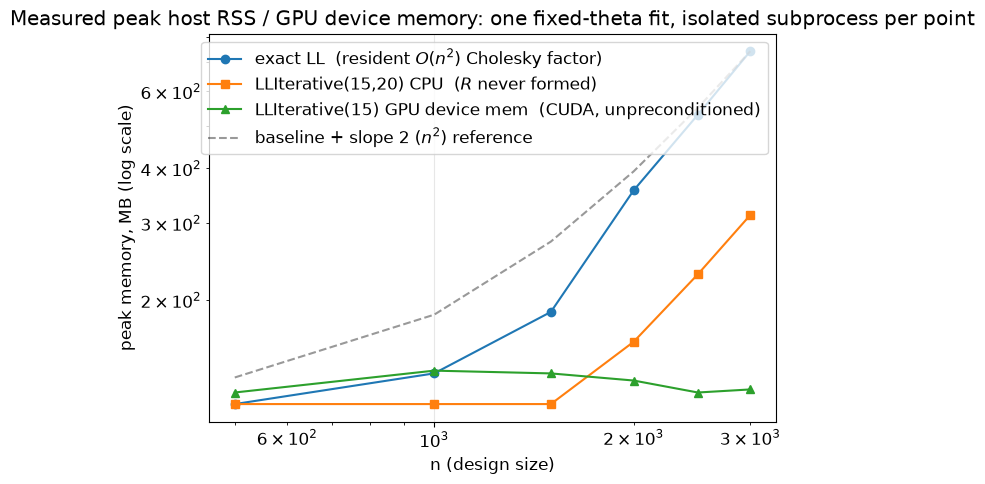

exact:                    116 MB at n=500 -> 741 MB at n=3000  (6.4x growth over a 6x increase in n)
LLIterative CPU (host):   116 MB at n=500 -> 313 MB at n=3000  (2.71x growth over a 6x increase in n)
LLIterative GPU (device): 123 MB at n=500 -> 125 MB at n=3000  (1.02x growth over a 6x increase in n)
LLIterative GPU (host):   143 MB at n=500 -> 312 MB at n=3000  (host RSS of the GPU-accelerated run -- also stays essentially flat, same as the CPU curve)

All host-RSS numbers include the same fixed Python+numpy+pylibkriging interpreter baseline
(tens of MB) -- that baseline dominates LLIterative's footprint at these n (nearly flat),
while the exact objective's resident L factor overtakes it and keeps growing as n^2.
The GPU device-memory curve is dominated by a fixed CUDA-context allocation, not by n --
R is never materialized on the device either, so it stays flat for the same reason the
host curves do.


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(n_values, mem_exact, 'o-', label='exact LL  (resident $O(n^2)$ Cholesky factor)')
ax.loglog(n_values, mem_iter_cpu, 's-',
          label=f'LLIterative({m_fixed},{precond_rank}) CPU  ($R$ never formed)')
ax.loglog(n_values, mem_iter_gpu_device, '^-',
          label=f'LLIterative({m_fixed}) GPU device mem  (CUDA, unpreconditioned)')

n_arr = np.array(n_values, dtype=float)
baseline = min(mem_exact[0], mem_iter_cpu[0])
ax.loglog(n_arr, baseline + (mem_exact[-1] - baseline) * (n_arr / n_arr[-1])**2,
          'k--', alpha=0.4, label=r'baseline + slope 2 ($n^2$) reference')

ax.set_xlabel('n (design size)')
ax.set_ylabel('peak memory, MB (log scale)')
ax.set_title('Measured peak host RSS / GPU device memory: one fixed-theta fit, isolated subprocess per point')
ax.legend()
plt.tight_layout()
plt.show()

print(f'exact:                    {mem_exact[0]:.0f} MB at n={n_values[0]} -> {mem_exact[-1]:.0f} MB at n={n_values[-1]}'
      f'  ({mem_exact[-1]/mem_exact[0]:.1f}x growth over a {n_values[-1]/n_values[0]:.0f}x increase in n)')
print(f'LLIterative CPU (host):   {mem_iter_cpu[0]:.0f} MB at n={n_values[0]} -> {mem_iter_cpu[-1]:.0f} MB at n={n_values[-1]}'
      f'  ({mem_iter_cpu[-1]/mem_iter_cpu[0]:.2f}x growth over a {n_values[-1]/n_values[0]:.0f}x increase in n)')
print(f'LLIterative GPU (device): {mem_iter_gpu_device[0]:.0f} MB at n={n_values[0]} -> {mem_iter_gpu_device[-1]:.0f} MB at n={n_values[-1]}'
      f'  ({mem_iter_gpu_device[-1]/max(mem_iter_gpu_device[0],1):.2f}x growth over a {n_values[-1]/n_values[0]:.0f}x increase in n)')
print(f'LLIterative GPU (host):   {mem_iter_gpu_host[0]:.0f} MB at n={n_values[0]} -> {mem_iter_gpu_host[-1]:.0f} MB at n={n_values[-1]}'
      f'  (host RSS of the GPU-accelerated run -- also stays essentially flat, same as the CPU curve)')
print()
print('All host-RSS numbers include the same fixed Python+numpy+pylibkriging interpreter baseline')
print('(tens of MB) -- that baseline dominates LLIterative\'s footprint at these n (nearly flat),')
print('while the exact objective\'s resident L factor overtakes it and keeps growing as n^2.')
print('The GPU device-memory curve is dominated by a fixed CUDA-context allocation, not by n --')
print('R is never materialized on the device either, so it stays flat for the same reason the')
print('host curves do.')


## Practical guidance

- The restart-heuristic fix (see the intro) is real and already merged —
  it turns unbounded, potentially-runaway fit times into bounded,
  predictable ones. It does **not** fix the remaining cost driver seen
  above: conjugate gradient itself not converging within its iteration
  budget on some $\theta$/design combinations, which every evaluation
  still pays for. That looks like a genuine follow-up question (a
  preconditioner — `objective="LLIterative(m,precond_rank)"` already
  exists and is worth trying by default — or a looser CG tolerance) rather
  than something this notebook should paper over.
- `LLIterative` is the right tool when you need $R$ to stay genuinely
  *exact* (no structural approximation of the covariance) while avoiding
  the $O(n^3)$ time / $O(n^2)$ memory of a dense factorization — its value
  proposition is at *large* $n$, not small $n$ like the example above
  (chosen small purely to keep this notebook's total runtime reasonable).
- If you need `LLIterative` in practice today: try the built-in
  Nystrom-Woodbury CG preconditioner
  (`objective="LLIterative(m,precond_rank)"`) first if fits are slow — it
  targets exactly the ill-conditioned-$R$ symptom observed here. A good
  starting $\theta$ (e.g. from a cheap `subsetOfData`-reduced exact fit)
  also shortens the number of BFGS iterations needed regardless.
- `predictIterative` (§3) is not stochastic — it's deterministic CG — and
  is thoroughly benchmarked (correctness + speed/memory scaling) in
  [predictiterative_vs_cholesky.ipynb](predictiterative_vs_cholesky.ipynb).
- Current limitation (v1): `NoiseModel::None` only; `simulate`/
  `update_simulate`/`save` are blocked on `LLIterative`-fitted models (no
  matrix-free sampling technique implemented yet).
- `optim="none"` at a fixed $\theta$ now genuinely commits a light
  `LLIterative` fit too (like `LLNystrom` always did) -- a fast, deterministic
  way to get an `LLIterative`-flavored model without paying for a BFGS search,
  useful whenever $\theta$ is already known. See
  `KrigingIterativeTest.cpp`'s "honors optim=none identically to optim=BFGS"
  test.

## References

- Ubaru, S., Chen, J., & Saad, Y. (2017). *Fast estimation of tr(f(A)) via
  stochastic Lanczos quadrature*. SIAM Journal on Matrix Analysis and
  Applications, 38(4), 1075-1099.
- Hutchinson, M. F. (1990). *A stochastic estimator of the trace of the
  influence matrix for Laplacian smoothing splines*. Communications in
  Statistics - Simulation and Computation, 19(2), 433-450.
- Gardner, J., Pleiss, G., Weinberger, K. Q., Bindel, D., & Wilson, A. G.
  (2018). *GPyTorch: Blackbox matrix-matrix Gaussian process inference
  with GPU acceleration*. Advances in Neural Information Processing
  Systems, 31 — the BBMM strategy this objective mirrors.
- Hestenes, M. R., & Stiefel, E. (1952). *Methods of conjugate gradients
  for solving linear systems*. Journal of Research of the National Bureau
  of Standards, 49(6), 409–436 — the original CG method underlying every
  matrix-free solve used here.

See also [Iterative.md](Iterative.md) for the full API reference,
[PredictIterative.md](PredictIterative.md) for the matrix-free predictor
this reuses, and [Scalability.md](Scalability.md) for how `LLIterative`
compares to `LLVecchia`, `LLNystrom`, `NestedKriging` and `subsetOfData`.